In [1]:
import sys
import os
import libcontext

In [2]:
import torch
# import numpy as np
# from typing import cast, List, Optional, Union
# from tqdm import tqdm
import pandas as pd
import seaborn as sns
# import time
# import math

from torch.optim import Optimizer

In [3]:
from src.adagram_fixed_rank import AdaGramFR
from src.adagram_projector_splitting import AdaGramPS
from src.shampoo import Shampoo

## Models

In [4]:
from torch import nn


class LinearRegressionModel(nn.Module):
    def __init__(self, dim_in, dim_out, seed=100):
        super(LinearRegressionModel, self).__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(dim_in, dim_out)
    
    def forward(self, x):
        return self.linear(x)
    

class MultiClassLogisticRegressionModel(nn.Module):
    def __init__(self, num_classes=2, dim=2):
        super(MultiClassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(dim, num_classes)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        return self.softmax(self.linear(x))
    
    
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim=2, seed=100):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x) 

In [5]:
model = LinearRegressionModel(dim_in=5, dim_out=2)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")  # Output: 12

# Check individual parameter shapes
for name, param in model.named_parameters():
    print(f"{name}: {param.shape} -> {param.numel()} parameters")

Total parameters: 12
linear.weight: torch.Size([2, 5]) -> 10 parameters
linear.bias: torch.Size([2]) -> 2 parameters


## Train

In [6]:
import os
import numpy as np
import torch

def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test, 
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model and evaluate on test data, saving gradients by epoch.
    """
    from tqdm import tqdm
    import time
    
    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)
                                                                                                                             
    if time_start is None:
        time_start = time.time()
    
    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()

        # Access and save gradients after backward() but before optimizer.step()
        grad_dict = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_dict[name] = param.grad.detach().cpu().numpy()

        # Save gradients to compressed numpy file per epoch
        grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
        if r is not None:
            grad_filename += f'_rank{r}'
        grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
        np.savez_compressed(grad_file, **grad_dict)

        optimizer.step()

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch

        avg_epoch_time = elapsed_time / (epoch + 1)
        
        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()
    
    return results, test_loss


In [7]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def train_model_stochastic(model, optimizer, criterion, results, X_train, y_train, X_test, y_test,
                          num_epochs, opt_name, lr, batch_size=32, shuffle=True, time_start=None,
                          r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model using stochastic gradient descent with mini-batches and evaluate on test data.

    Args:
        batch_size (int): Size of mini-batches for stochastic training
        shuffle (bool): Whether to shuffle training data each epoch
    """
    from tqdm import tqdm
    import time

    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    # Create DataLoader for stochastic training
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)

    if time_start is None:
        time_start = time.time()

    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        epoch_loss = 0.0
        num_batches = 0

        # Stochastic training loop over mini-batches
        for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass on mini-batch
            y_pred = model(batch_X)
            batch_loss = criterion(y_pred, batch_y)

            # Backward pass
            batch_loss.backward()

            # Save gradients from the last batch of each epoch
            if batch_idx == len(train_loader) - 1:
                grad_dict = {}
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_dict[name] = param.grad.detach().cpu().numpy()

                # Save gradients to compressed numpy file per epoch
                grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
                if r is not None:
                    grad_filename += f'_rank{r}'
                grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
                np.savez_compressed(grad_file, **grad_dict)

            # Update parameters
            optimizer.step()

            epoch_loss += batch_loss.item()
            num_batches += 1
        
        y_pred_train = model(X_train)
        y_pred_test = model(X_test)
        
        train_loss = criterion(y_pred_train, y_train)
        test_loss = criterion(y_pred_test, y_test)

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch
        avg_epoch_time = elapsed_time / (epoch + 1)

        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': test_loss,
            'mode': "test", 
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time,
            'batch_size': batch_size
        })

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss,
            'mode': "train", 
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time,
            'batch_size': batch_size
        })

    # Final evaluation on test set
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()

    return results, test_loss


## Data generation 

In [8]:
from src.preprocessing.dataset import SparseDataset, CorrelatedDataset, LinearDataset

## Pipeline

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.001, 0.01, 0.1]
num_epochs = 50
ranks = [2]
in_dims = [20]
out_dims = [2]
ds = SparseDataset(n_samples=100, in_dim=in_dims[0], out_dim=out_dims[0])
X, y = ds.create_data()

print(X)
print(y)


print("cond", torch.linalg.cond(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

optimizers = {
    # 'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
    # 'FullMatrixAdaGrad': lambda params, lr: FullMatrixAdaGrad(params, lr=lr),
    'AdaGramPS': lambda params, lr, max_rank: AdaGramPS(params=params, lr=lr, max_rank=max_rank, log_file="results/loggs/psi_adagram_logs.csv"),
    'AdaGramFR_svd': lambda params, lr, max_rank: AdaGramFR(True, params, lr=lr, max_rank=max_rank),
    'AdaGramFR_nosvd': lambda params, lr, max_rank: AdaGramFR(False, params, lr=lr, max_rank=max_rank),
    # 'Vanilla_SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
    'Torch_Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
}
models = {}
all_train_losses = {}
all_test_losses = {}
results = []

final_parameters = {}

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
        criterion = nn.CrossEntropyLoss()
        # criterion = nn.MSELoss()
        print(opt_name)
        if opt_name in ["AdaGramFR_nosvd", "AdaGramFR_svd", "AdaGramPS"]:
            for rank in ranks:
                # model = LinearRegressionModel(dim_in=in_dims[0], dim_out=out_dims[0], seed=100)
                model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
                optimizer = opt_fn(model.parameters(), lr, max_rank=rank)
                epoch_results, test_loss = train_model_stochastic(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                    r=rank,
                    batch_size=1
                )
                print("weight", model.state_dict()['linear.weight'].detach(),)
                final_parameters[f"{opt_name}_rank_{rank}_lr_{lr}"] = {
                    'weights': model.state_dict()['linear.weight'].clone().detach(),
                    'bias': model.state_dict()['linear.bias'].clone().detach(),
                    'final_loss': test_loss
                }
        else:
            # model = LinearRegressionModel(dim_in=in_dims[0], dim_out=2, seed=100)
            model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
            optimizer = opt_fn(model.parameters(), lr)
            epoch_results, test_loss = train_model_stochastic(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                    batch_size=1
                )
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
# df['train_loss'] = df['train_loss'].astype(float)
df.to_csv(f'results/no_svd_adagrad_{in_dims[0]}_by_{out_dims[0]}.csv')
# print(f"end {dim}")


tensor([[ 0.0000e+00, -1.6293e+00,  1.3810e-01,  ...,  6.5034e-02,
          1.1662e-01,  1.6936e-03],
        [ 0.0000e+00,  0.0000e+00, -4.3594e-01,  ..., -4.8010e-02,
         -1.2872e-01,  7.3888e-02],
        [ 0.0000e+00,  0.0000e+00,  7.3193e-01,  ..., -8.3081e-02,
          4.9816e-02, -1.2000e-01],
        ...,
        [ 0.0000e+00,  0.0000e+00, -3.1140e-01,  ..., -2.0043e-01,
          5.5123e-04,  4.6033e-02],
        [ 0.0000e+00,  0.0000e+00, -6.6567e-01,  ..., -1.5076e-01,
         -1.7679e-02, -1.6129e-01],
        [ 2.2777e+00, -3.1508e+00,  5.5943e-01,  ...,  1.4394e-01,
         -9.4881e-02,  1.0380e-02]])
tensor([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
        1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0])
cond tensor(15.5695)
AdaGra

100%|██████████| 50/50 [00:19<00:00,  2.58it/s]


weight tensor([[-0.1893,  0.0015, -0.4208, -0.1888, -0.1307,  0.1271, -0.0653, -0.1761,
         -0.1087, -0.1192, -0.1620,  0.1382,  0.0981,  0.1409, -0.0292,  0.2367,
          0.2545,  0.1414, -0.0789, -0.0337],
        [-0.0743,  0.3384,  0.3934,  0.4488,  0.2384,  0.2406,  0.1224,  0.0207,
         -0.0831,  0.0918,  0.0591, -0.0921,  0.1805,  0.0073, -0.1695, -0.1282,
          0.2244,  0.1194, -0.1415,  0.1736]])
AdaGramPS


100%|██████████| 50/50 [00:24<00:00,  2.08it/s]


weight tensor([[-0.3656, -0.7798, -1.5924, -0.9231, -1.0315,  0.0934,  0.0472, -0.1716,
         -0.0696,  0.0497, -0.3351,  0.2585,  0.0129,  0.1328, -0.0635,  0.4636,
          0.3214,  0.1758,  0.0854,  0.1697],
        [ 0.2077,  1.2255,  1.6707,  1.2888,  1.2450,  0.3801,  0.1156,  0.1219,
         -0.0165,  0.0287,  0.3379, -0.1066,  0.3715,  0.1212, -0.0295, -0.2493,
          0.2632,  0.1908, -0.2001,  0.0760]])
AdaGramPS


...

100%|██████████| 50/50 [00:04<00:00, 11.24it/s]


Torch_Adagrad


100%|██████████| 50/50 [00:04<00:00, 11.46it/s]


Torch_Adagrad


100%|██████████| 50/50 [00:04<00:00, 11.07it/s]


In [13]:
df = pd.read_csv('results/loggs/nosvd_adagram_logs.csv')
# df_1["method"] = ["svd"] * len(df_1['lr'])
# df_2 = pd.read_csv('results/loggs/nosvd_adagram_logs.csv')
# df_2["method"] = ["nosvd"] * len(df_2['lr'])
# df = pd.concat([df_2])


## Adagram Statistics

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


lr_values = df['lr'].unique()
methods = df['method'].unique()
param_id = 0
params = {0:"weights", 1:"bias"}

for method in methods:
    for lr in lr_values:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        subset = df[df['lr'] == lr]
        param_subset = subset.query('param_id == @param_id and method == @method')
        ax1.plot(param_subset['step'], np.abs(param_subset['max_U']), label=f'max_U')
        ax1.plot(param_subset['step'], np.abs(param_subset['min_U']), label=f'min_U')
        ax2.plot(param_subset['step'], np.abs(param_subset['max_V']), label=f'max_V')
        ax2.plot(param_subset['step'], np.abs(param_subset['min_V']), label=f'min_V')
        # ax3.plot(param_subset['step'], param_subset['Lt_norm'], label=f'Lt abs max')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Value')
        ax1.set_title('Matrix U')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Value')
        ax2.set_title('Matrix V')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale("log") 
    
    
        plt.suptitle(f'Plots for lr={lr} for {params[param_id]}, method={method}')
        plt.tight_layout()
        plt.show()


KeyError: 'method'

c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


<Figure size 1500x800 with 0 Axes>

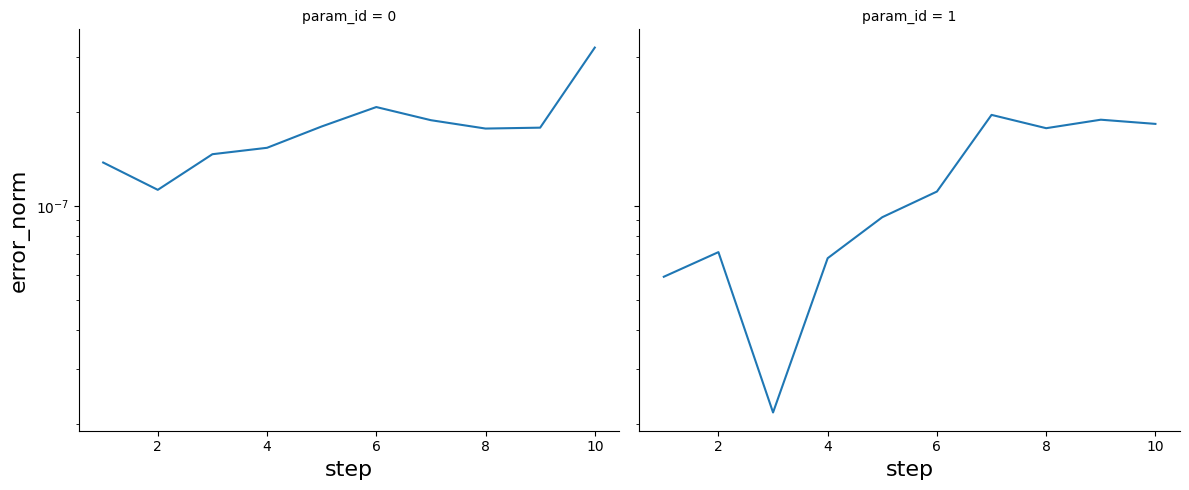

In [12]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df,
    col='param_id',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='step',
    # y='avg_epoch_time',
    y='error_norm',
    # hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
# grid.add_legend(title='optimizer', title_fontsize='15', fontsize='12')

# grid.fig.suptitle(f'LinRegression({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="param_id = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()

## Convergence

In [10]:
df = pd.read_csv(f'results/no_svd_adagrad_{in_dims[0]}_by_{out_dims[0]}.csv')
# df_1 = pd.read_csv(f'results/no_svd_adagrad__{in_dims[0]}_by_{out_dims[0]}.csv')
# df_2 = pd.read_csv(f'results/adagrad_{in_dims[0]}_by_{out_dims[0]}.csv')
# df = pd.concat([df_1["optimizer == 'AdaGramFR_nosvd rank 2'"], df_2])
# df = pd.concat([df_1, df_2])
# df['loss'] = df['loss'].astype(float)
df.head()


,Unnamed: 0,epoch,optimizer,lr,loss,mode,rank,avg_epoch_time,epoch_time,batch_size
0,0,0,AdaGramPS rank 2,0.001,0.637626,test,2.0,0.403090,0.403090,1
1,1,0,AdaGramPS rank 2,0.001,0.677622,train,2.0,0.403090,0.403090,1
2,2,1,AdaGramPS rank 2,0.001,0.634294,test,2.0,0.409711,0.416331,1
3,3,1,AdaGramPS rank 2,0.001,0.673038,train,2.0,0.409711,0.416331,1
4,4,2,AdaGramPS rank 2,0.001,0.631039,test,2.0,0.407010,0.401607,1


<Figure size 1500x800 with 0 Axes>

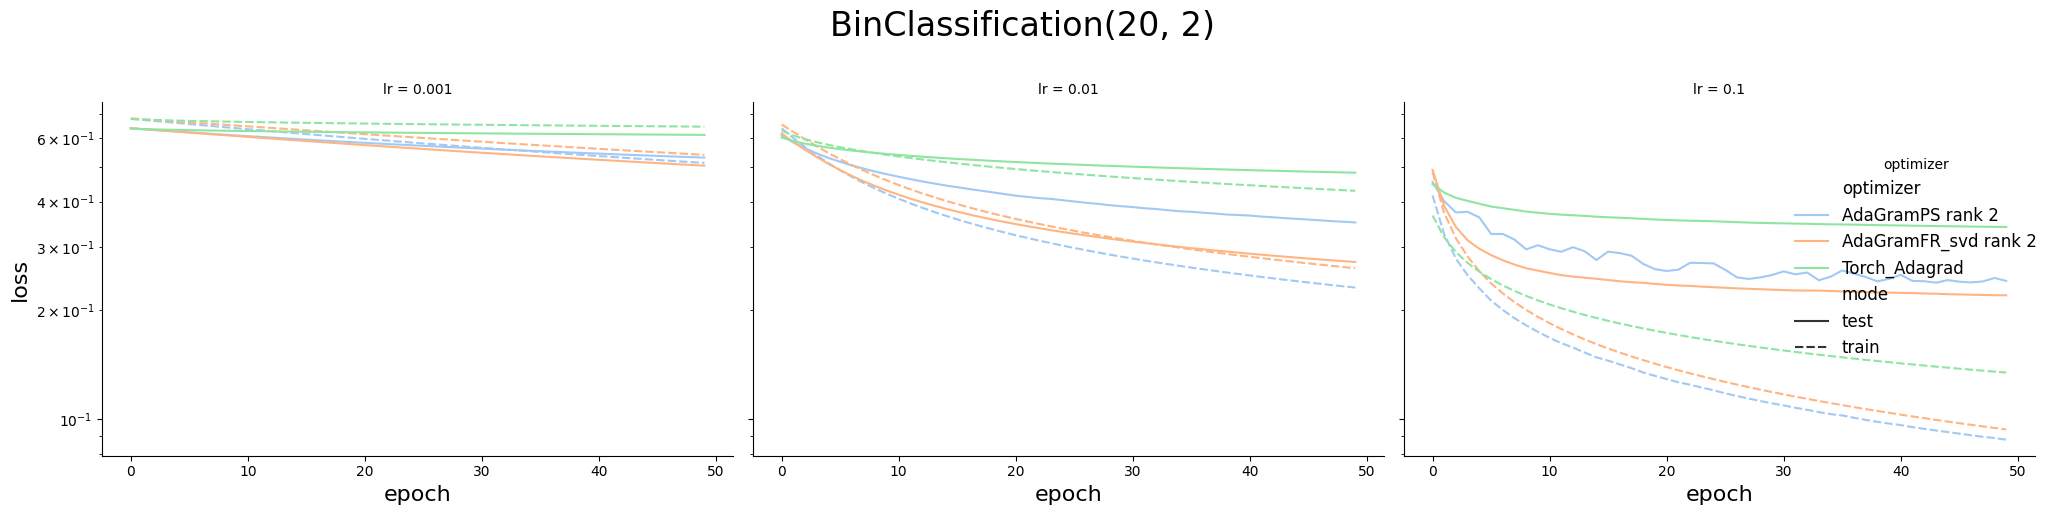

In [11]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df.query("optimizer != 'AdaGramFR_nosvd rank 2'"),
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    # y='avg_epoch_time',
    y='loss',
    style='mode',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='optimizer', title_fontsize='15', fontsize='12')

# grid.fig.suptitle(f'LinRegression({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
                  fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="lr = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()

## Weights/gradients analysis


Epoch 0 - linear.weight: Shape (2, 20), Values added: 40
Epoch 1 - linear.weight: Shape (2, 20), Values added: 40
Epoch 2 - linear.weight: Shape (2, 20), Values added: 40
Total epochs found: 301, Total gradient values: 12040
Stored 12040 values for Torch_Adagrad_lr0.01_linear.weight

Epoch 0 - linear.bias: Shape (2,), Values added: 2
Epoch 1 - linear.bias: Shape (2,), Values added: 2
Epoch 2 - linear.bias: Shape (2,), Values added: 2
Total epochs found: 301, Total gradient values: 602
Stored 602 values for Torch_Adagrad_lr0.01_linear.bias

Epoch 0 - linear.weight: Shape (2, 20), Values added: 40
Epoch 1 - linear.weight: Shape (2, 20), Values added: 40
Epoch 2 - linear.weight: Shape (2, 20), Values added: 40
Total epochs found: 301, Total gradient values: 12040
Stored 12040 values for Vanilla_SGD_lr0.01_linear.weight

Epoch 0 - linear.bias: Shape (2,), Values added: 2
Epoch 1 - linear.bias: Shape (2,), Values added: 2
Epoch 2 - linear.bias: Shape (2,), Values added: 2
Total epochs foun

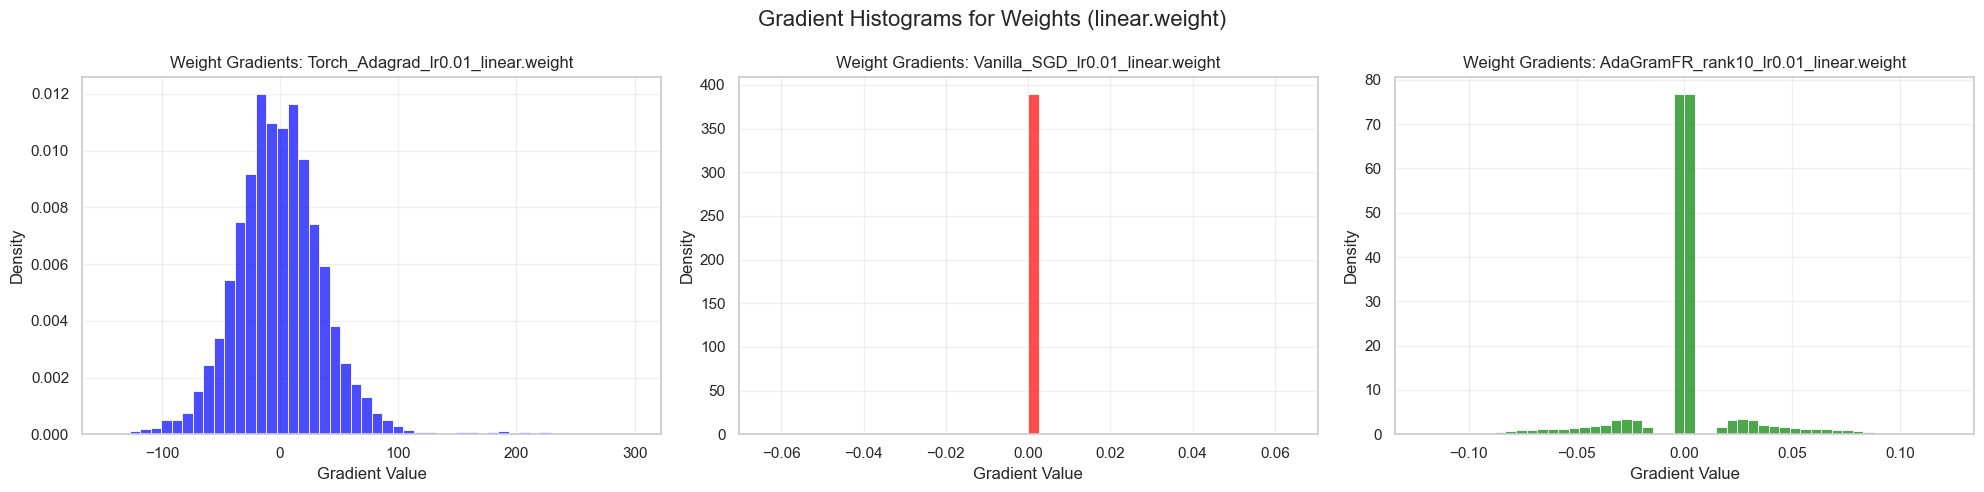

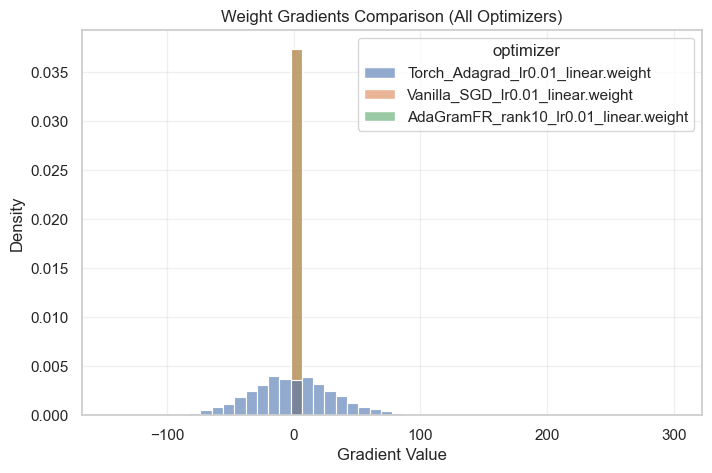

Bias gradients for Torch_Adagrad_lr0.01_linear.bias: Mean=-0.124040, Std=7.437228, Min=-22.958122, Max=33.789925
Bias gradients for Vanilla_SGD_lr0.01_linear.bias: Mean=0.000000, Std=0.000553, Min=-0.009590, Max=0.009590
Bias gradients for AdaGramFR_rank10_lr0.01_linear.bias: Mean=0.000000, Std=0.006158, Min=-0.046603, Max=0.046603


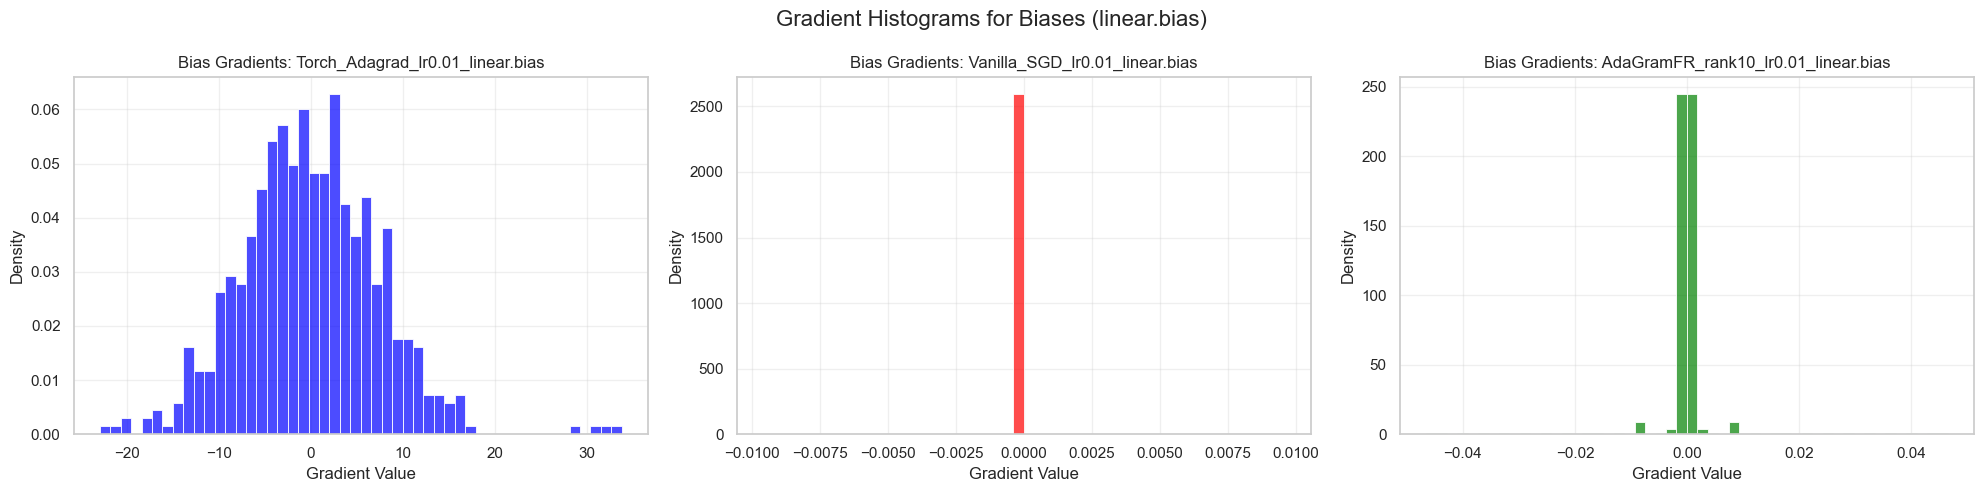

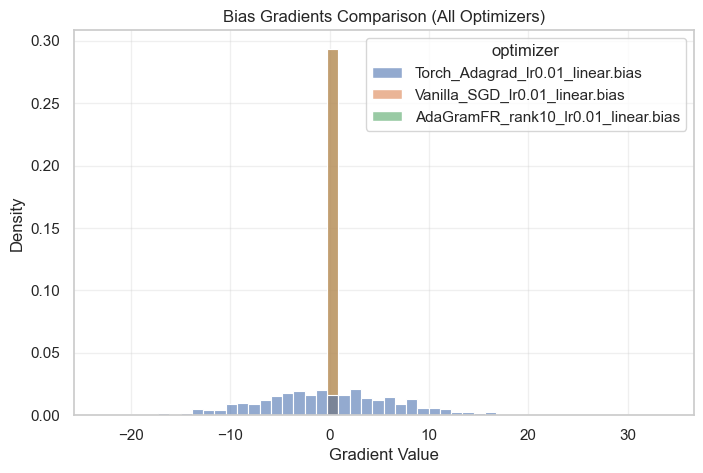


Gradient statistics saved to 'gradient_value_statistics.csv'
Total collections processed: 6


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']
lr_values = [0.01]
param_names = ['linear.weight', 'linear.bias']
ranks = [10]  # Add this for AdaGramFR
start_epoch = 0
end_epoch = 300

def clean_gradient_values(grad_values, max_value=1e17):
    """Clean gradient values by handling infinite and very large values."""
    grad_clean = np.array(grad_values)
    # Replace positive infinity
    grad_clean = np.where(np.isposinf(grad_clean), max_value, grad_clean)
    # Replace negative infinity  
    grad_clean = np.where(np.isneginf(grad_clean), -max_value, grad_clean)
    # Replace NaN values with 0
    grad_clean = np.where(np.isnan(grad_clean), 0, grad_clean)
    return grad_clean

def collect_all_gradient_values(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Collect all gradient values from all epochs for a specific parameter."""
    all_grad_values = []
    epochs_found = 0
    
    for epoch in range(start_epoch, end_epoch + 1):
        if rank is not None:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        else:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
            
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    # Flatten the gradient array and extend the list
                    all_grad_values.extend(grad.flatten())
                    epochs_found += 1
                    
                    # Print statistics for first few epochs
                    if epoch < 3:
                        print(f"Epoch {epoch} - {param_name}: Shape {grad.shape}, "
                              f"Values added: {grad.size}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 3:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    print(f"Total epochs found: {epochs_found}, Total gradient values: {len(all_grad_values)}")
    return np.array(all_grad_values)

# Dictionary to store all gradient values
gradient_collections = {}

# Collect gradient values for all optimizers and parameters
for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\n{'='*60}")
            print(f"Collecting gradients for {optimizer}, lr={lr}, param={param_name}")
            
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    key = f"{optimizer}_rank{r}_lr{lr}_{param_name}"
                    grad_values = collect_all_gradient_values(
                        optimizer, lr, param_name, start_epoch, end_epoch, rank=r
                    )
                    if len(grad_values) > 0:
                        gradient_collections[key] = clean_gradient_values(grad_values)
                        print(f"Stored {len(gradient_collections[key])} values for {key}")
            else:
                key = f"{optimizer}_lr{lr}_{param_name}"
                grad_values = collect_all_gradient_values(
                    optimizer, lr, param_name, start_epoch, end_epoch
                )
                if len(grad_values) > 0:
                    gradient_collections[key] = clean_gradient_values(grad_values)
                    print(f"Stored {len(gradient_collections[key])} values for {key}")

# Create comprehensive histograms using Seaborn
if gradient_collections:
    print(f"\n{'='*60}")
    print("Creating histograms...")
    
    # Separate collections by parameter type
    weight_collections = {k: v for k, v in gradient_collections.items() if 'linear.weight' in k}
    bias_collections = {k: v for k, v in gradient_collections.items() if 'linear.bias' in k}
    
    # Plot histograms for weights using Seaborn
    if weight_collections:
        n_weight_collections = len(weight_collections)
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes = axes.flatten()
        fig.suptitle('Gradient Histograms for Weights (linear.weight)', fontsize=16)
        
        colors = ['blue', 'red', 'green', 'orange', 'purple']
        
        # Individual histograms for each optimizer
        for idx, (key, values) in enumerate(weight_collections.items()):
            if idx < len(axes):
                # Create DataFrame for seaborn
                df_temp = pd.DataFrame({'gradient_values': values, 'optimizer': key})
                
                sns.histplot(data=df_temp, x='gradient_values', bins=50, 
                           color=colors[idx % len(colors)], alpha=0.7, 
                           stat='density', ax=axes[idx])
                
                axes[idx].set_xlabel('Gradient Value')
                axes[idx].set_ylabel('Density')
                axes[idx].set_title(f'Weight Gradients: {key}')
                axes[idx].grid(True, alpha=0.3)
                
                print(f"Weight gradients for {key}: "
                      f"Mean={np.mean(values):.6f}, Std={np.std(values):.6f}, "
                      f"Min={np.min(values):.6f}, Max={np.max(values):.6f}")
        
        # Hide unused subplots
        for idx in range(n_weight_collections, len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        # Overlapping histogram for weights comparison using Seaborn
        plt.figure(figsize=(8, 5))
        
        # Combine all weight data into a single DataFrame
        combined_weight_data = []
        for key, values in weight_collections.items():
            temp_df = pd.DataFrame({
                'gradient_values': values,
                'optimizer': key
            })
            combined_weight_data.append(temp_df)
        
        if combined_weight_data:
            weight_df = pd.concat(combined_weight_data, ignore_index=True)
            
            sns.histplot(data=weight_df, x='gradient_values', hue='optimizer', 
                        bins=50, alpha=0.6, stat='density', multiple='layer')
            
            plt.xlabel('Gradient Value')
            plt.ylabel('Density')
            plt.title('Weight Gradients Comparison (All Optimizers)')
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # Plot histograms for biases using Seaborn
    if bias_collections:
        n_bias_collections = len(bias_collections)
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes = axes.flatten()
        fig.suptitle('Gradient Histograms for Biases (linear.bias)', fontsize=16)
        
        # Individual histograms for each optimizer
        for idx, (key, values) in enumerate(bias_collections.items()):
            if idx < len(axes):
                # Create DataFrame for seaborn
                df_temp = pd.DataFrame({'gradient_values': values, 'optimizer': key})
                
                sns.histplot(data=df_temp, x='gradient_values', bins=50, 
                           color=colors[idx % len(colors)], alpha=0.7, 
                           stat='density', ax=axes[idx])
                
                axes[idx].set_xlabel('Gradient Value')
                axes[idx].set_ylabel('Density')
                axes[idx].set_title(f'Bias Gradients: {key}')
                axes[idx].grid(True, alpha=0.3)
                
                print(f"Bias gradients for {key}: "
                      f"Mean={np.mean(values):.6f}, Std={np.std(values):.6f}, "
                      f"Min={np.min(values):.6f}, Max={np.max(values):.6f}")
        
        # Hide unused subplots
        for idx in range(n_bias_collections, len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        # Overlapping histogram for biases comparison using Seaborn
        plt.figure(figsize=(8, 5))
        
        # Combine all bias data into a single DataFrame
        combined_bias_data = []
        for key, values in bias_collections.items():
            temp_df = pd.DataFrame({
                'gradient_values': values,
                'optimizer': key
            })
            combined_bias_data.append(temp_df)
        
        if combined_bias_data:
            bias_df = pd.concat(combined_bias_data, ignore_index=True)
            
            sns.histplot(data=bias_df, x='gradient_values', hue='optimizer', 
                        bins=50, alpha=0.6, stat='density', multiple='layer')
            
            plt.xlabel('Gradient Value')
            plt.ylabel('Density')
            plt.title('Bias Gradients Comparison (All Optimizers)')
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # Save gradient statistics
    stats_data = []
    for key, values in gradient_collections.items():
        stats_data.append({
            'collection': key,
            'total_values': len(values),
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values)
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_csv('gradient_value_statistics.csv', index=False)
    print(f"\nGradient statistics saved to 'gradient_value_statistics.csv'")
    print(f"Total collections processed: {len(gradient_collections)}")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")



Reading gradients for Torch_Adagrad, lr=0.01, param=linear.weight
Epoch 0 - linear.weight:
  Shape: (2, 20)
  Norm: 720.269287
  Std: 97.396858
Epoch 1 - linear.weight:
  Shape: (2, 20)
  Norm: 888.304688
  Std: 82.108025
Epoch 2 - linear.weight:
  Shape: (2, 20)
  Norm: 182.531693
  Std: 15.561522
Epoch 3 - linear.weight:
  Shape: (2, 20)
  Norm: 877.494324
  Std: 98.928055
Epoch 4 - linear.weight:
  Shape: (2, 20)
  Norm: 273.689178
  Std: 43.270992
Successfully read 301 epochs

Reading gradients for Torch_Adagrad, lr=0.01, param=linear.bias
Epoch 0 - linear.bias:
  Shape: (2,)
  Norm: 32.491497
  Std: 19.582821
Epoch 1 - linear.bias:
  Shape: (2,)
  Norm: 34.295525
  Std: 13.961367
Epoch 2 - linear.bias:
  Shape: (2,)
  Norm: 8.337633
  Std: 3.074322
Epoch 3 - linear.bias:
  Shape: (2,)
  Norm: 29.021320
  Std: 14.556944
Epoch 4 - linear.bias:
  Shape: (2,)
  Norm: 14.974397
  Std: 10.587732
Successfully read 301 epochs

Reading gradients for Vanilla_SGD, lr=0.01, param=linear.weig

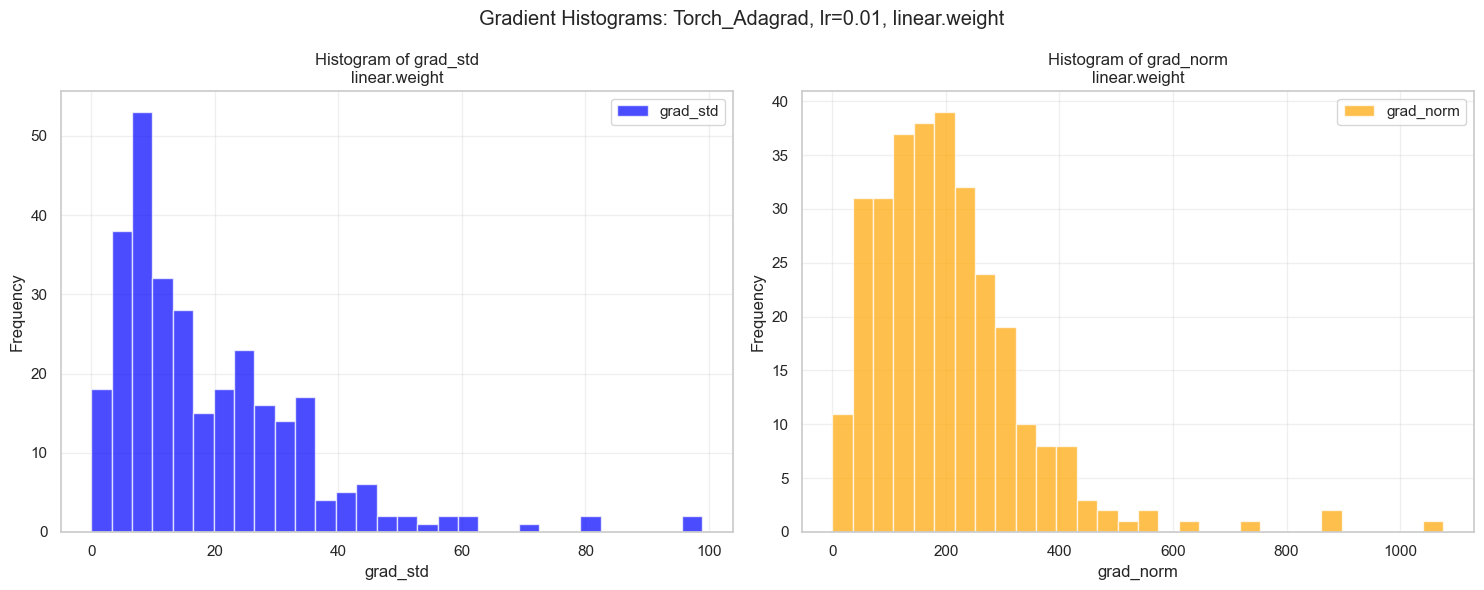

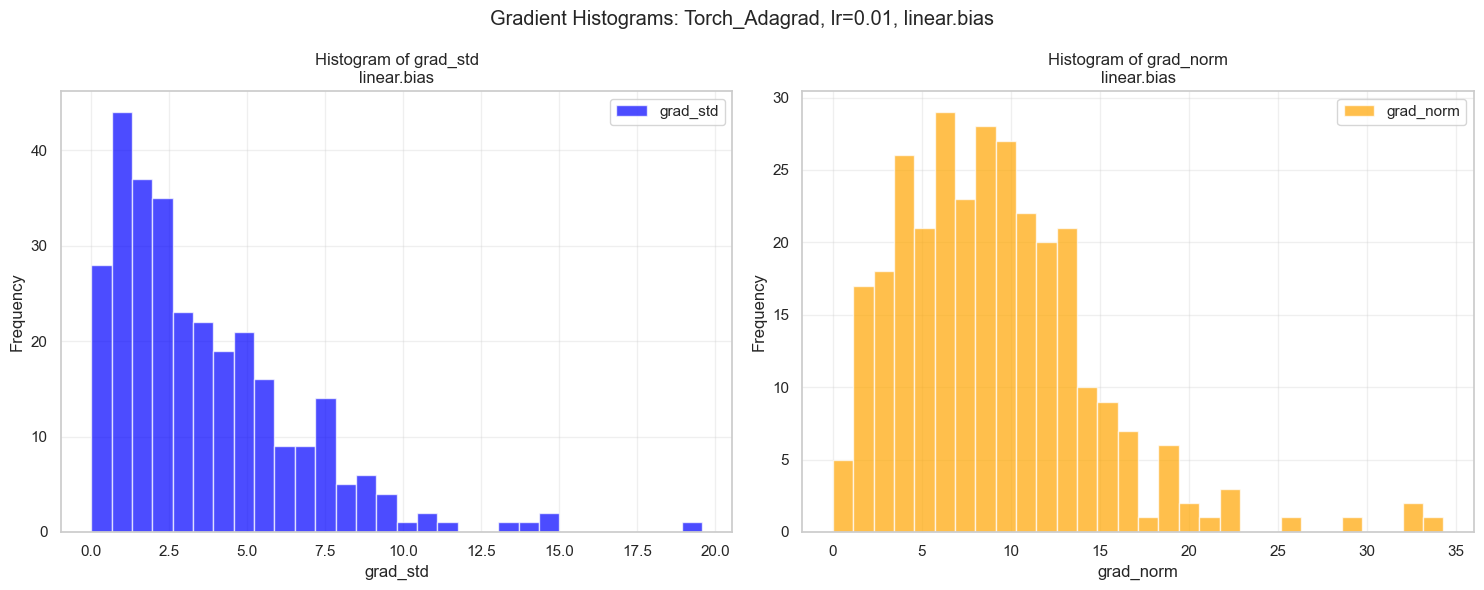

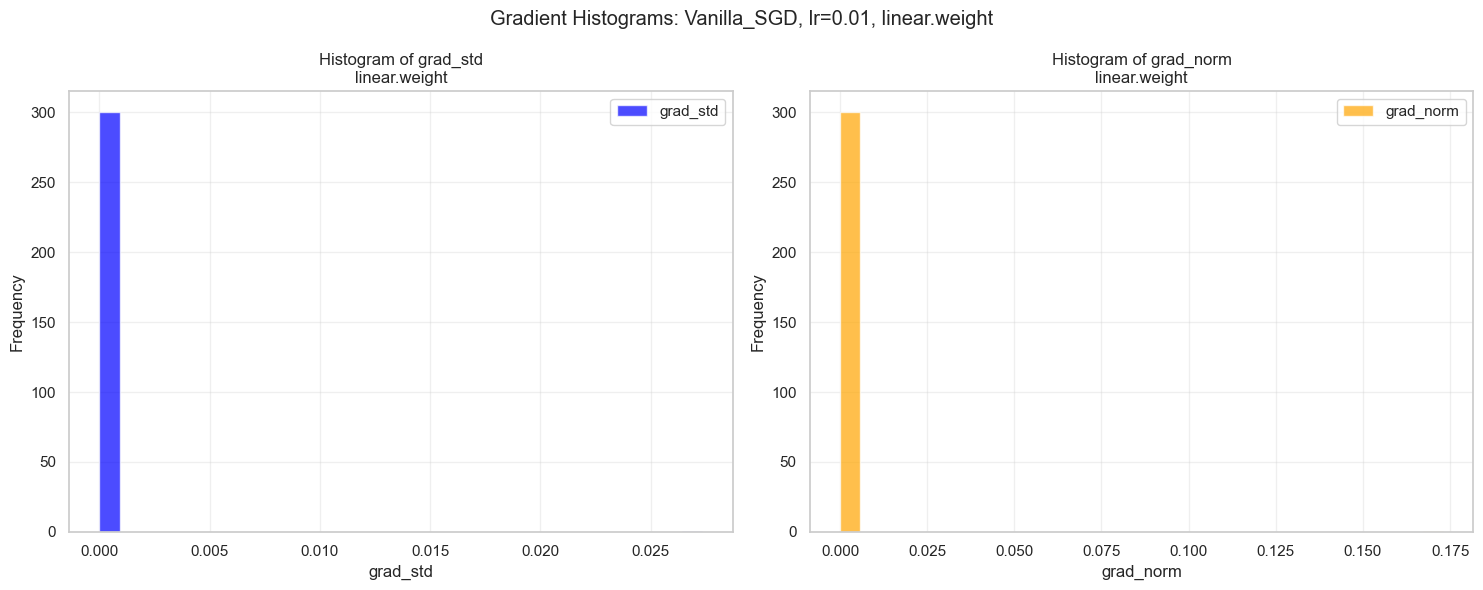

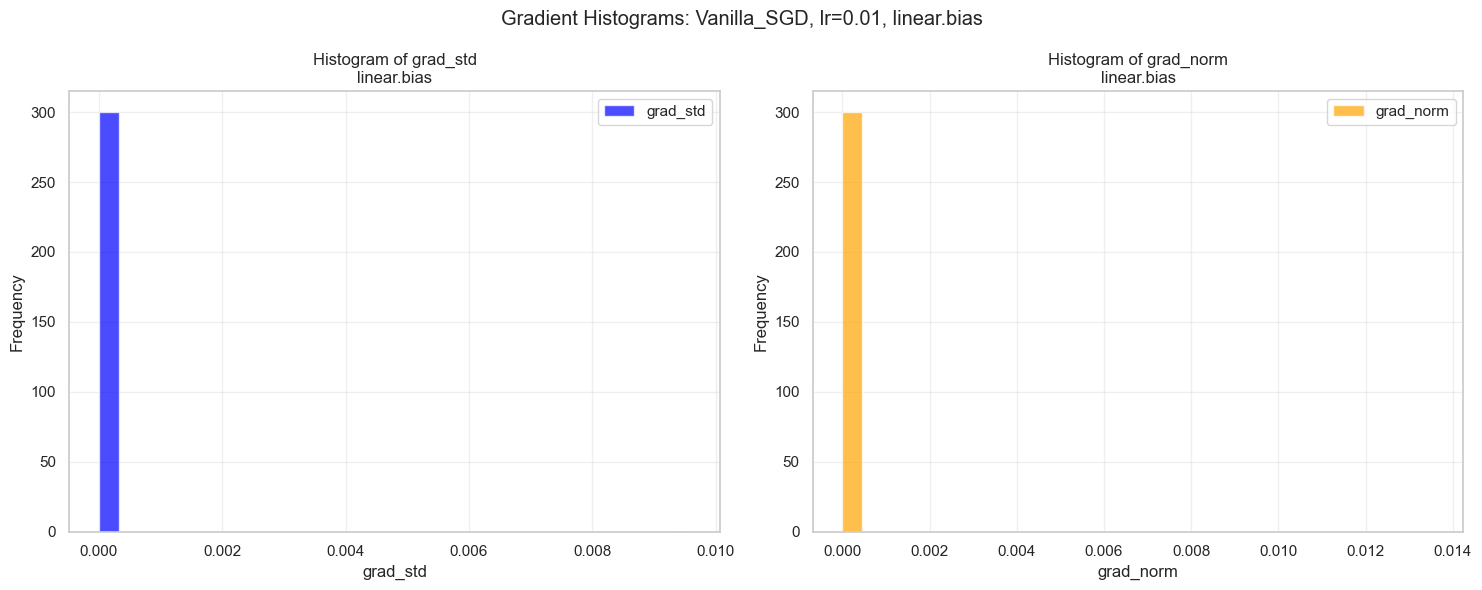

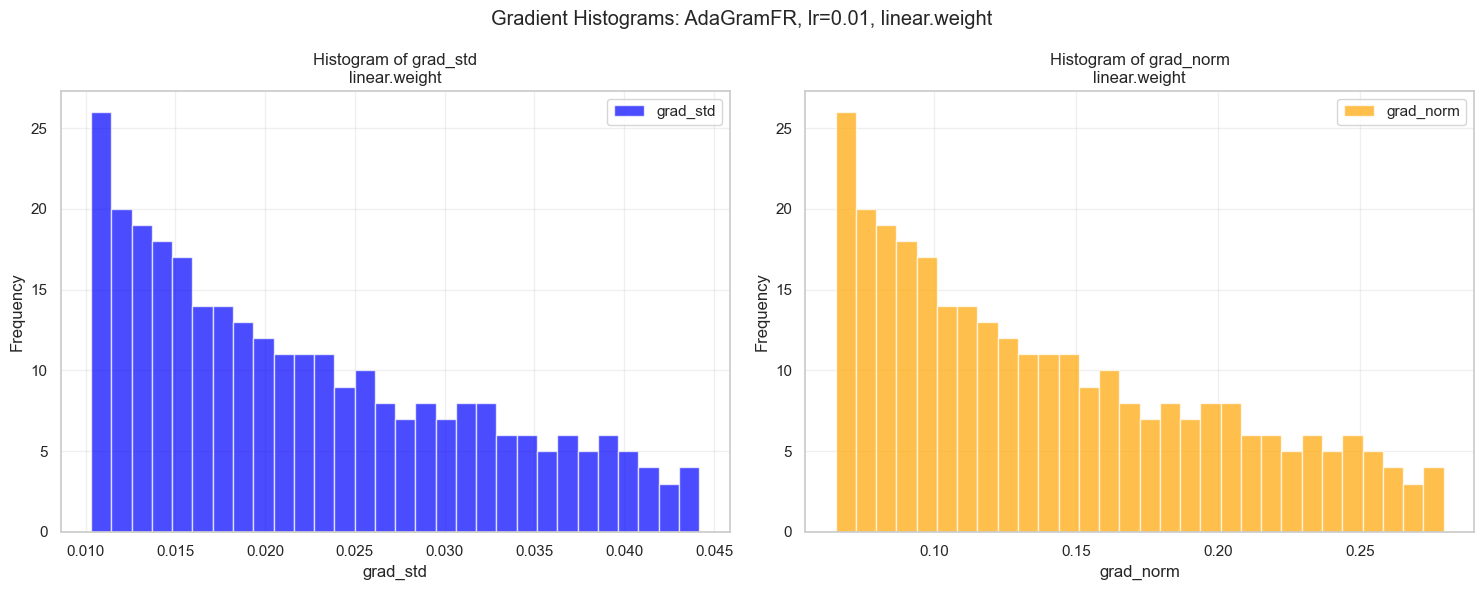

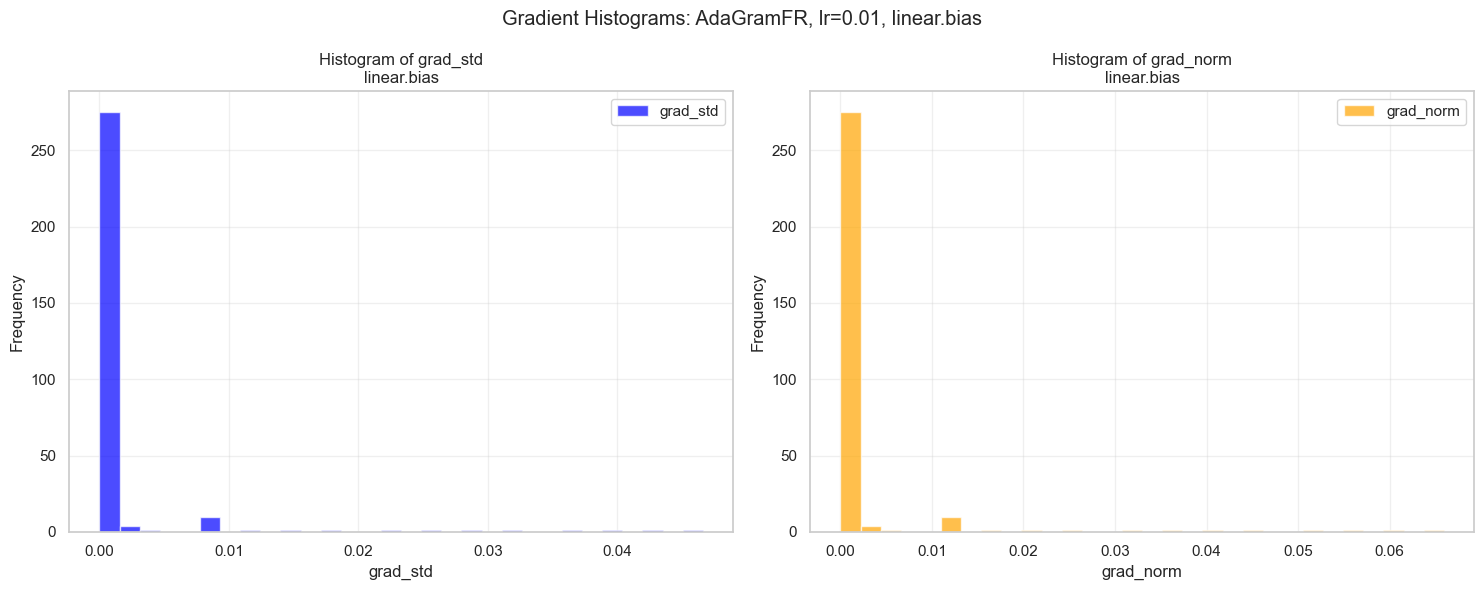


Gradient statistics saved to 'gradient_statistics.csv'


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']  # Add your optimizers
lr_values = [0.01]  # Add your learning rates
param_names = ['linear.weight', 'linear.bias']
start_epoch = 0
end_epoch = 300

def clean_gradient_data(df, max_value=1e17):
    """Clean gradient data by handling infinite and very large values."""
    df_clean = df.copy()
    
    # Replace infinite values
    for col in ['grad_norm', 'grad_std']:
        if col in df_clean.columns:
            # Replace positive infinity
            df_clean[col] = np.where(np.isposinf(df_clean[col]), max_value, df_clean[col])
            # Replace negative infinity  
            df_clean[col] = np.where(np.isneginf(df_clean[col]), -max_value, df_clean[col])
            # Replace NaN values with 0
            df_clean[col] = np.where(np.isnan(df_clean[col]), 0, df_clean[col])
    
    return df_clean


# Function to read gradients for all epochs
def read_gradient_stats(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Read gradient statistics from saved files for all epochs."""
    epochs = []
    grad_norms = []
    grad_stds = []
    grad_values = []
    
    for epoch in range(start_epoch, end_epoch + 1):
        grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
        if rank:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    grad_norm = np.linalg.norm(grad)
                    grad_std = np.std(grad)
                    
                    epochs.append(epoch)
                    grad_norms.append(grad_norm)
                    grad_stds.append(grad_std)
                    
                    # Print statistics for first few epochs
                    if epoch < 5:
                        print(f"Epoch {epoch} - {param_name}:")
                        print(f"  Shape: {grad.shape}")
                        print(f"  Norm: {grad_norm:.6f}")
                        print(f"  Std: {grad_std:.6f}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 5:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    return pd.DataFrame({
        'epoch': epochs,
        'grad_norm': grad_norms,
        'grad_std': grad_stds,
        'optimizer': optimizer,
        'lr': lr,
        'param_name': param_name
    })

# Read gradient statistics for all optimizers and parameters
all_grad_stats = []

for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\nReading gradients for {optimizer}, lr={lr}, param={param_name}")
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch, rank=r)
            else:
                grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch)
            if not grad_stats.empty:
                all_grad_stats.append(grad_stats)
                print(f"Successfully read {len(grad_stats)} epochs")
            else:
                print(f"No data found for {optimizer}, lr={lr}, param={param_name}")

# Combine all gradient statistics
if all_grad_stats:
    combined_df = pd.concat(all_grad_stats, ignore_index=True)
    combined_df = clean_gradient_data(combined_df)
    print(f"\nTotal gradient records: {len(combined_df)}")
    print(combined_df.head())
    
    # Create histograms for each optimizer and parameter
    for optimizer in combined_df['optimizer'].unique():
        for lr in combined_df['lr'].unique():
            for param_name in combined_df['param_name'].unique():
                subset = combined_df[
                    (combined_df['optimizer'] == optimizer) & 
                    (combined_df['lr'] == lr) & 
                    (combined_df['param_name'] == param_name)
                ]
                
                if not subset.empty:
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Plot histogram of grad_std
                    ax1.hist(subset['grad_std'], bins=30, color='blue', alpha=0.7, label='grad_std')
                    ax1.set_xlabel('grad_std')
                    ax1.set_ylabel('Frequency')
                    ax1.set_title(f'Histogram of grad_std\n{param_name}')
                    ax1.legend()
                    ax1.grid(True, alpha=0.3)
                    
                    # Plot histogram of grad_norm
                    ax2.hist(subset['grad_norm'], bins=30, color='orange', alpha=0.7, label='grad_norm')
                    ax2.set_xlabel('grad_norm')
                    ax2.set_ylabel('Frequency')
                    ax2.set_title(f'Histogram of grad_norm\n{param_name}')
                    ax2.legend()
                    ax2.grid(True, alpha=0.3)
                    
                    plt.suptitle(f'Gradient Histograms: {optimizer}, lr={lr}, {param_name}')
                    plt.tight_layout()
                    plt.show()
    
    # Save combined statistics to CSV
    combined_df.to_csv('gradient_statistics.csv', index=False)
    print("\nGradient statistics saved to 'gradient_statistics.csv'")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")



Reading gradients for Torch_Adagrad, lr=0.1, param=linear.weight
Epoch 0 - linear.weight:
  Shape: (2, 20)
  Norm: 178.176834
  Std: 27.478662
Epoch 1 - linear.weight:
  Shape: (2, 20)
  Norm: 445.290314
  Std: 38.654732
Epoch 2 - linear.weight:
  Shape: (2, 20)
  Norm: 34.268715
  Std: 1.692012
Epoch 3 - linear.weight:
  Shape: (2, 20)
  Norm: 601.857849
  Std: 70.778465
Epoch 4 - linear.weight:
  Shape: (2, 20)
  Norm: 244.179031
  Std: 38.562565
Successfully read 300 epochs

Reading gradients for Torch_Adagrad, lr=0.1, param=linear.bias
Epoch 0 - linear.bias:
  Shape: (2,)
  Norm: 8.037593
  Std: 5.540932
Epoch 1 - linear.bias:
  Shape: (2,)
  Norm: 17.191696
  Std: 6.551920
Epoch 2 - linear.bias:
  Shape: (2,)
  Norm: 1.565317
  Std: 0.300248
Epoch 3 - linear.bias:
  Shape: (2,)
  Norm: 19.905210
  Std: 10.423700
Epoch 4 - linear.bias:
  Shape: (2,)
  Norm: 13.359802
  Std: 9.435453
Successfully read 300 epochs

Reading gradients for Vanilla_SGD, lr=0.1, param=linear.weight
Epoch 

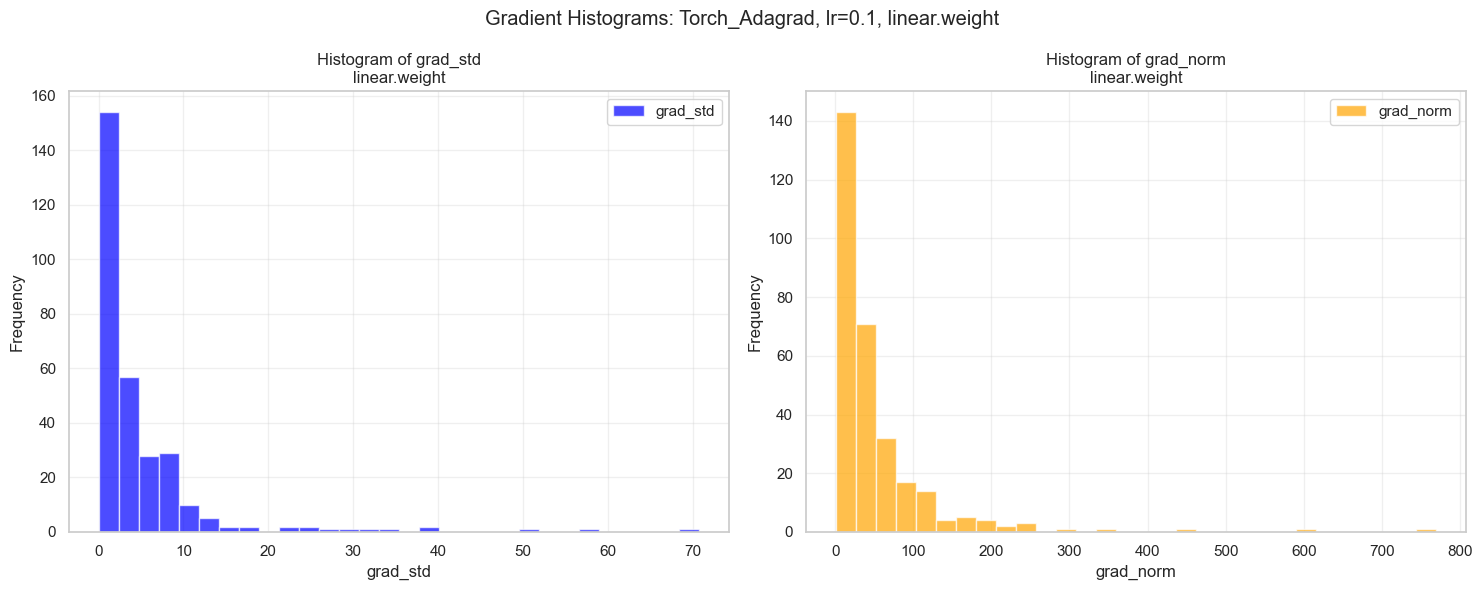

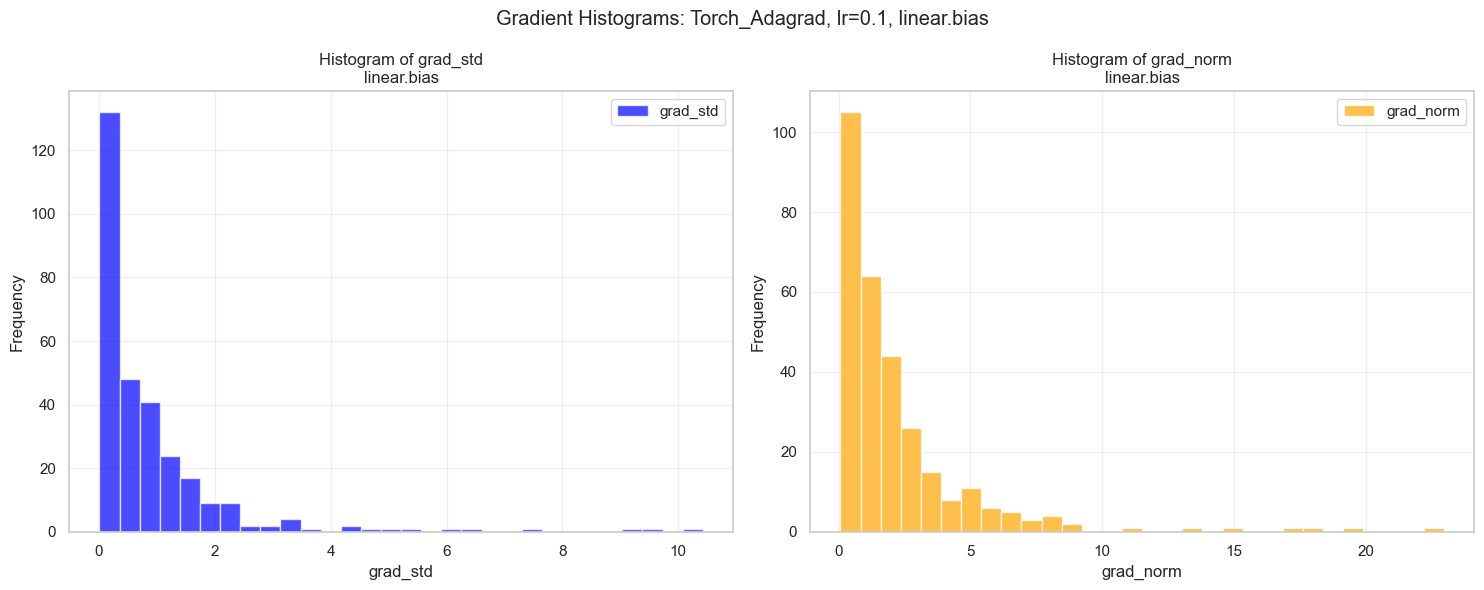

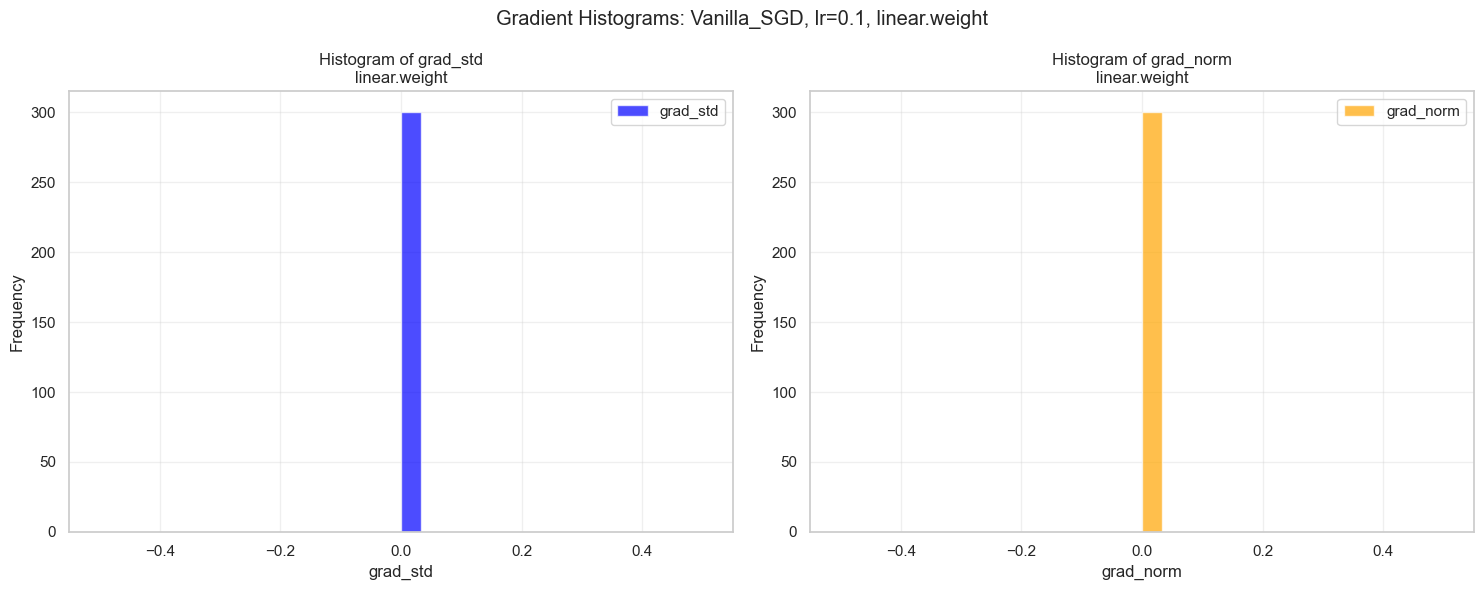

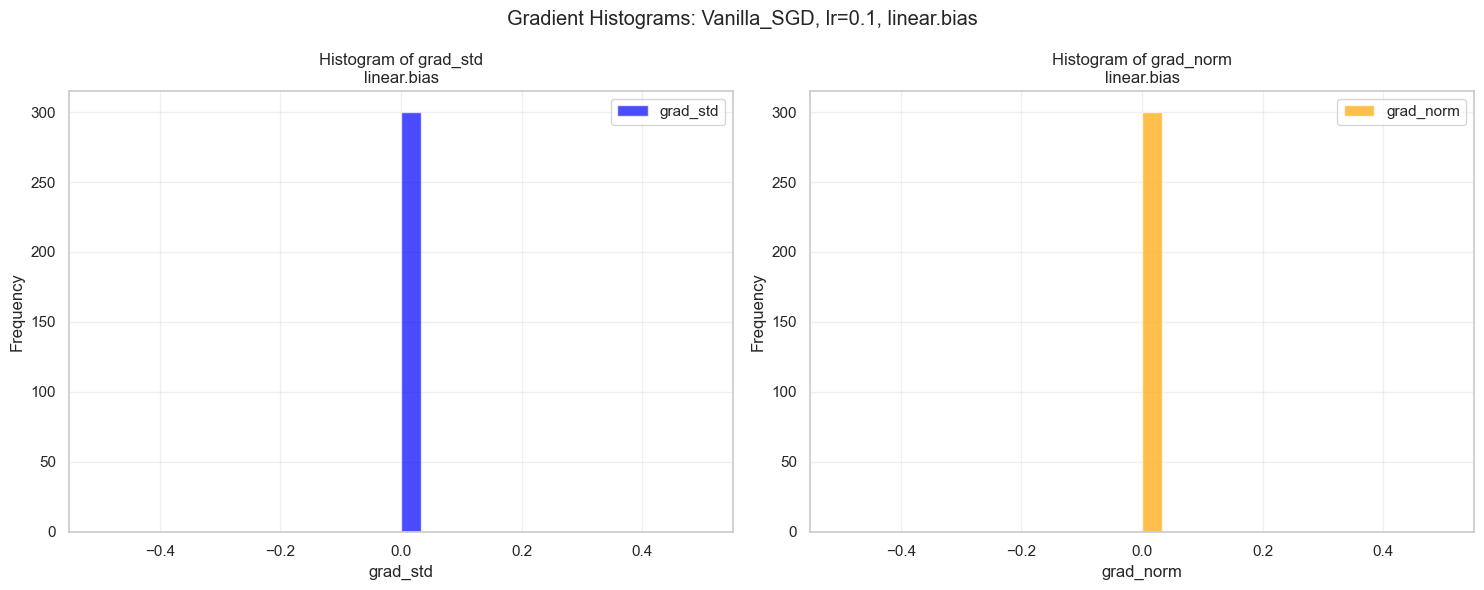


Gradient statistics saved to 'gradient_statistics.csv'


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']  # Add your optimizers
lr_values = [0.1]  # Add your learning rates
param_names = ['linear.weight', 'linear.bias']
start_epoch = 0
end_epoch = 300

def clean_gradient_data(df, max_value=1e17):
    """Clean gradient data by handling infinite and very large values."""
    df_clean = df.copy()
    
    # Replace infinite values
    for col in ['grad_norm', 'grad_std']:
        if col in df_clean.columns:
            # Replace positive infinity
            df_clean[col] = np.where(np.isposinf(df_clean[col]), max_value, df_clean[col])
            # Replace negative infinity  
            df_clean[col] = np.where(np.isneginf(df_clean[col]), -max_value, df_clean[col])
            # Replace NaN values with 0
            df_clean[col] = np.where(np.isnan(df_clean[col]), 0, df_clean[col])
    
    return df_clean


# Function to read gradients for all epochs
def read_gradient_stats(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Read gradient statistics from saved files for all epochs."""
    epochs = []
    grad_norms = []
    grad_stds = []
    grad_values = []
    
    for epoch in range(start_epoch, end_epoch + 1):
        grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
        if rank:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    grad_norm = np.linalg.norm(grad)
                    grad_std = np.std(grad)
                    
                    epochs.append(epoch)
                    grad_norms.append(grad_norm)
                    grad_stds.append(grad_std)
                    
                    # Print statistics for first few epochs
                    if epoch < 5:
                        print(f"Epoch {epoch} - {param_name}:")
                        print(f"  Shape: {grad.shape}")
                        print(f"  Norm: {grad_norm:.6f}")
                        print(f"  Std: {grad_std:.6f}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 5:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    return pd.DataFrame({
        'epoch': epochs,
        'grad_norm': grad_norms,
        'grad_std': grad_stds,
        'optimizer': optimizer,
        'lr': lr,
        'param_name': param_name
    })

# Read gradient statistics for all optimizers and parameters
all_grad_stats = []

for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\nReading gradients for {optimizer}, lr={lr}, param={param_name}")
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch, rank=r)
            else:
                grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch)
            if not grad_stats.empty:
                all_grad_stats.append(grad_stats)
                print(f"Successfully read {len(grad_stats)} epochs")
            else:
                print(f"No data found for {optimizer}, lr={lr}, param={param_name}")

# Combine all gradient statistics
if all_grad_stats:
    combined_df = pd.concat(all_grad_stats, ignore_index=True)
    combined_df = clean_gradient_data(combined_df)
    print(f"\nTotal gradient records: {len(combined_df)}")
    print(combined_df.head())
    
    # Create histograms for each optimizer and parameter
    for optimizer in combined_df['optimizer'].unique():
        for lr in combined_df['lr'].unique():
            for param_name in combined_df['param_name'].unique():
                subset = combined_df[
                    (combined_df['optimizer'] == optimizer) & 
                    (combined_df['lr'] == lr) & 
                    (combined_df['param_name'] == param_name)
                ]
                
                if not subset.empty:
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Plot histogram of grad_std
                    ax1.hist(subset['grad_std'], bins=30, color='blue', alpha=0.7, label='grad_std')
                    ax1.set_xlabel('grad_std')
                    ax1.set_ylabel('Frequency')
                    ax1.set_title(f'Histogram of grad_std\n{param_name}')
                    ax1.legend()
                    ax1.grid(True, alpha=0.3)
                    
                    # Plot histogram of grad_norm
                    ax2.hist(subset['grad_norm'], bins=30, color='orange', alpha=0.7, label='grad_norm')
                    ax2.set_xlabel('grad_norm')
                    ax2.set_ylabel('Frequency')
                    ax2.set_title(f'Histogram of grad_norm\n{param_name}')
                    ax2.legend()
                    ax2.grid(True, alpha=0.3)
                    
                    plt.suptitle(f'Gradient Histograms: {optimizer}, lr={lr}, {param_name}')
                    plt.tight_layout()
                    plt.show()
    
    # Save combined statistics to CSV
    combined_df.to_csv('gradient_statistics.csv', index=False)
    print("\nGradient statistics saved to 'gradient_statistics.csv'")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")
